## Load Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## load Dataset

In [3]:
df = pd.read_csv("customer_lifetime_value_data.csv")

## First Look

In [4]:
df

,order_id,customer_id,order_date,category,quantity,unit_price,discount,payment_method,delivery_days,satisfaction_score,...,product_cost,shipping_cost,returned,return_cost,marketing_cost,profit,customer_age,customer_gender,region,customer_tenure_months
0,ORD_017871,CUST_00001,2024-01-30,Fashion,4,12607.88,0.31,UPI,5,4,...,25645.30,128.26,0,0.00,378.14,8646.05,56,Female,East,5
1,ORD_005444,CUST_00001,2024-03-02,Grocery,5,7601.31,0.25,Cash,4,5,...,13230.74,96.49,0,0.00,164.33,15013.35,56,Female,East,5
2,ORD_013064,CUST_00001,2024-10-20,Home,1,24517.05,0.04,Net Banking,3,1,...,10925.92,197.43,0,0.00,25.83,12387.19,56,Female,East,5
3,ORD_013278,CUST_00001,2025-02-16,Grocery,5,14150.85,0.30,Net Banking,2,4,...,29243.11,127.34,0,0.00,387.13,19770.40,56,Female,East,5
4,ORD_014339,CUST_00001,2025-06-16,Fashion,3,13378.61,0.13,Cash,5,1,...,19888.63,439.19,1,3775.06,363.41,10451.88,56,Female,East,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,ORD_000787,CUST_05000,2024-03-08,Home,3,18090.01,0.13,Cash,3,3,...,29716.15,272.09,0,0.00,188.47,17038.22,36,Male,Central,47
19996,ORD_007152,CUST_05000,2024-07-31,Sports,4,12067.88,0.12,Credit Card,2,1,...,20296.47,249.35,0,0.00,230.94,21702.18,36,Male,Central,47
19997,ORD_005336,CUST_05000,2026-01-07,Electronics,3,21619.32,0.01,Credit Card,3,2,...,29646.96,327.68,0,0.00,203.84,34030.90,36,Male,Central,47
19998,ORD_011603,CUST_05000,2026-05-22,Grocery,5,12637.32,0.29,Net Banking,1,2,...,24530.90,99.86,1,7303.80,60.75,12867.18,36,Male,Central,47


In [5]:
df.head()

,order_id,customer_id,order_date,category,quantity,unit_price,discount,payment_method,delivery_days,satisfaction_score,...,product_cost,shipping_cost,returned,return_cost,marketing_cost,profit,customer_age,customer_gender,region,customer_tenure_months
0,ORD_017871,CUST_00001,2024-01-30,Fashion,4,12607.88,0.31,UPI,5,4,...,25645.30,128.26,0,0.00,378.14,8646.05,56,Female,East,5
1,ORD_005444,CUST_00001,2024-03-02,Grocery,5,7601.31,0.25,Cash,4,5,...,13230.74,96.49,0,0.00,164.33,15013.35,56,Female,East,5
2,ORD_013064,CUST_00001,2024-10-20,Home,1,24517.05,0.04,Net Banking,3,1,...,10925.92,197.43,0,0.00,25.83,12387.19,56,Female,East,5
3,ORD_013278,CUST_00001,2025-02-16,Grocery,5,14150.85,0.30,Net Banking,2,4,...,29243.11,127.34,0,0.00,387.13,19770.40,56,Female,East,5
4,ORD_014339,CUST_00001,2025-06-16,Fashion,3,13378.61,0.13,Cash,5,1,...,19888.63,439.19,1,3775.06,363.41,10451.88,56,Female,East,5


In [6]:
df.shape

(20000, 23)

In [7]:
df.columns

Index(['order_id', 'customer_id', 'order_date', 'category', 'quantity',
       'unit_price', 'discount', 'payment_method', 'delivery_days',
       'satisfaction_score', 'gross_amount', 'discount_amount', 'total_amount',
       'product_cost', 'shipping_cost', 'returned', 'return_cost',
       'marketing_cost', 'profit', 'customer_age', 'customer_gender', 'region',
       'customer_tenure_months'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                20000 non-null  object 
 1   customer_id             20000 non-null  object 
 2   order_date              20000 non-null  object 
 3   category                20000 non-null  object 
 4   quantity                20000 non-null  int64  
 5   unit_price              20000 non-null  float64
 6   discount                20000 non-null  float64
 7   payment_method          20000 non-null  object 
 8   delivery_days           20000 non-null  int64  
 9   satisfaction_score      20000 non-null  int64  
 10  gross_amount            20000 non-null  float64
 11  discount_amount         20000 non-null  float64
 12  total_amount            20000 non-null  float64
 13  product_cost            20000 non-null  float64
 14  shipping_cost           20000 non-null

In [10]:
df.isnull().sum()

order_id                  0
customer_id               0
order_date                0
category                  0
quantity                  0
unit_price                0
discount                  0
payment_method            0
delivery_days             0
satisfaction_score        0
gross_amount              0
discount_amount           0
total_amount              0
product_cost              0
shipping_cost             0
returned                  0
return_cost               0
marketing_cost            0
profit                    0
customer_age              0
customer_gender           0
region                    0
customer_tenure_months    0
dtype: int64

## Unique Customers

In [12]:
df["customer_id"].nunique()

4924

In [13]:
df.describe()

,quantity,unit_price,discount,delivery_days,satisfaction_score,gross_amount,discount_amount,total_amount,product_cost,shipping_cost,returned,return_cost,marketing_cost,profit,customer_age,customer_tenure_months
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,2.998500,12556.565939,0.174594,4.994650,3.004400,37784.675591,6607.330681,31177.344911,18769.958697,262.790019,0.121700,468.951168,210.687753,11464.957267,41.14550,30.609000
std,1.417885,7217.946563,0.100801,2.585509,1.413429,30004.299701,7168.610413,25203.151669,15600.589484,135.762811,0.326947,1772.236942,109.906231,10385.359998,13.59459,17.398616
min,1.000000,102.510000,0.000000,1.000000,1.000000,121.840000,0.000000,82.188900,51.300000,30.040000,0.000000,0.000000,20.010000,-830.000000,18.00000,1.000000
25%,2.000000,6252.735000,0.090000,3.000000,2.000000,13833.350000,1414.914600,11284.338600,6617.552500,145.082500,0.000000,0.000000,114.790000,3502.260000,29.00000,15.000000
50%,3.000000,12628.740000,0.180000,5.000000,3.000000,29321.760000,4032.575400,23834.939950,14272.055000,261.240000,0.000000,0.000000,211.185000,8303.915000,41.00000,31.000000
75%,4.000000,18859.662500,0.260000,7.000000,4.000000,56532.345000,9380.134125,46168.112375,27522.662500,380.232500,0.000000,0.000000,305.762500,16909.087500,53.00000,46.000000
max,5.000000,24999.800000,0.350000,9.000000,5.000000,124982.400000,43695.995000,123571.206000,86264.470000,499.980000,1.000000,22824.040000,399.980000,64189.060000,64.00000,60.000000


In [20]:
print("Total Revenue:", df["total_amount"].sum())
print("Total Profit:", df["profit"].sum())
print("Average Order Value:", df["total_amount"].mean())
print("Average Profit per Order:", df["profit"].mean())
print("Total Orders:", df["order_id"].nunique())
print("Total Customers:", df["customer_id"].nunique())

Total Revenue: 623546898.2174
Total Profit: 229299145.35
Average Order Value: 31177.344910869997
Average Profit per Order: 11464.9572675
Total Orders: 20000
Total Customers: 4924


## Revenue vs Profit

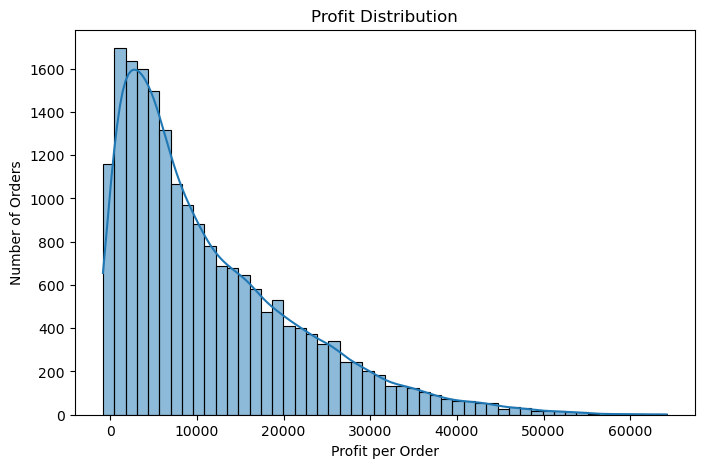

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["profit"],
    bins=50,
    kde=True
)

plt.title("Profit Distribution")
plt.xlabel("Profit per Order")
plt.ylabel("Number of Orders")

plt.show()

## Category Performance

In [18]:
category_profit = (
    df.groupby("category")
      .agg(
          orders=("order_id", "count"),
          revenue=("total_amount", "sum"),
          profit=("profit", "sum")
      )
      .sort_values("profit", ascending=False)
)

category_profit

,orders,revenue,profit
category,,,
Grocery,3406,1.061026e+08,39133570.56
Sports,3371,1.058250e+08,39024440.12
Fashion,3304,1.033747e+08,38145293.05
Beauty,3279,1.036101e+08,37959645.78
Home,3271,1.020194e+08,37582895.99
Electronics,3369,1.026151e+08,37453299.85


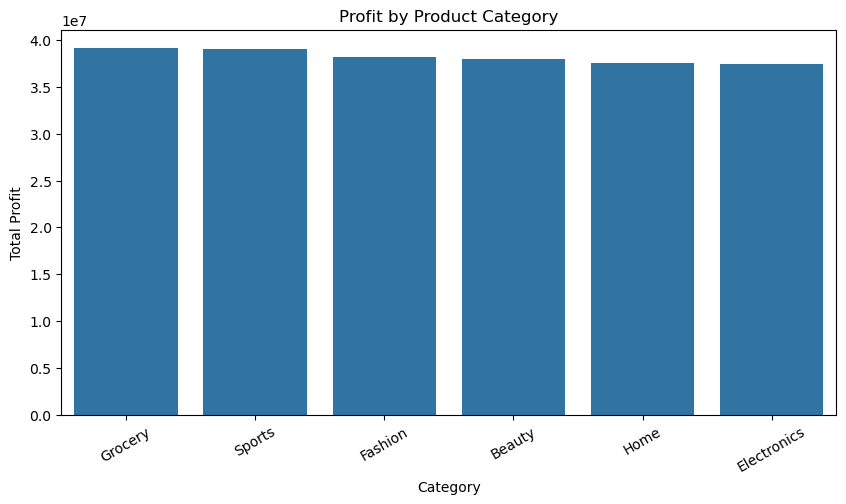

In [19]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_profit.reset_index(),
    x="category",
    y="profit"
)

plt.title("Profit by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=30)

plt.show()

## Customer Summary

In [23]:
customer_df = df.groupby("customer_id").agg(
    total_orders=("order_id", "count"),
    total_revenue=("total_amount", "sum"),
    total_profit=("profit", "sum"),
    total_quantity=("quantity", "sum"),
    total_discount=("discount_amount", "sum"),
    total_shipping_cost=("shipping_cost", "sum"),
    total_marketing_cost=("marketing_cost", "sum"),
    total_return_cost=("return_cost", "sum"),
    total_returns=("returned", "sum"),
    avg_order_value=("total_amount", "mean"),
    avg_profit_per_order=("profit", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
    avg_delivery_days=("delivery_days", "mean")
).reset_index()

customer_df.head()

,customer_id,total_orders,total_revenue,total_profit,total_quantity,total_discount,total_shipping_cost,total_marketing_cost,total_return_cost,total_returns,avg_order_value,avg_profit_per_order,avg_satisfaction,avg_delivery_days
0,CUST_00001,6,179435.1234,69138.82,21,56574.1766,1239.13,1620.36,3775.06,1,29905.853900,11523.136667,2.666667,3.833333
1,CUST_00002,3,19942.4568,6521.34,4,7535.0332,970.26,569.59,0.00,0,6647.485600,2173.780000,3.666667,2.666667
2,CUST_00003,1,80470.8576,19204.55,4,15327.7824,264.84,105.83,14351.04,1,80470.857600,19204.550000,1.000000,7.000000
3,CUST_00004,7,245089.3898,78490.58,24,61025.0802,1811.25,1334.32,0.00,0,35012.769971,11212.940000,3.285714,4.571429
4,CUST_00005,1,34991.1408,6616.24,2,4771.5192,278.41,89.42,6957.57,1,34991.140800,6616.240000,5.000000,3.000000


## Customer Information Add Karo

In [25]:
customer_info = df[
    [
        "customer_id",
        "customer_age",
        "customer_gender",
        "region",
        "customer_tenure_months"
    ]
].drop_duplicates("customer_id")

customer_df = customer_df.merge(
    customer_info,
    on="customer_id",
    how="left"
)

customer_df.head()

,customer_id,total_orders,total_revenue,total_profit,total_quantity,total_discount,total_shipping_cost,total_marketing_cost,total_return_cost,total_returns,avg_order_value,avg_profit_per_order,avg_satisfaction,avg_delivery_days,customer_age,customer_gender,region,customer_tenure_months
0,CUST_00001,6,179435.1234,69138.82,21,56574.1766,1239.13,1620.36,3775.06,1,29905.853900,11523.136667,2.666667,3.833333,56,Female,East,5
1,CUST_00002,3,19942.4568,6521.34,4,7535.0332,970.26,569.59,0.00,0,6647.485600,2173.780000,3.666667,2.666667,46,Other,Central,2
2,CUST_00003,1,80470.8576,19204.55,4,15327.7824,264.84,105.83,14351.04,1,80470.857600,19204.550000,1.000000,7.000000,32,Female,North,51
3,CUST_00004,7,245089.3898,78490.58,24,61025.0802,1811.25,1334.32,0.00,0,35012.769971,11212.940000,3.285714,4.571429,60,Male,West,56
4,CUST_00005,1,34991.1408,6616.24,2,4771.5192,278.41,89.42,6957.57,1,34991.140800,6616.240000,5.000000,3.000000,25,Female,Central,20


## RFM Features

In [27]:
df["order_date"] = pd.to_datetime(df["order_date"])

reference_date = df["order_date"].max()

recency = (
    df.groupby("customer_id")["order_date"]
      .max()
      .reset_index()
)

recency["recency_days"] = (
    reference_date - recency["order_date"]
).dt.days

recency = recency[
    ["customer_id", "recency_days"]
]

customer_df = customer_df.merge(
    recency,
    on="customer_id",
    how="left"
)

In [28]:
customer_df[
    [
        "customer_id",
        "recency_days",
        "total_orders",
        "total_revenue",
        "total_profit"
    ]
].head(10)

,customer_id,recency_days,total_orders,total_revenue,total_profit
0,CUST_00001,375,6,179435.1234,69138.82
1,CUST_00002,166,3,19942.4568,6521.34
2,CUST_00003,614,1,80470.8576,19204.55
3,CUST_00004,74,7,245089.3898,78490.58
4,CUST_00005,554,1,34991.1408,6616.24
5,CUST_00006,27,3,169570.7284,75769.42
6,CUST_00007,152,4,144123.9512,33880.64
7,CUST_00008,96,8,316965.1964,126688.14
8,CUST_00009,298,3,25478.9571,11182.20
9,CUST_00010,403,4,133066.0145,42372.59


## Profit Margin

In [30]:
customer_df["profit_margin"] = (
    customer_df["total_profit"]
    / customer_df["total_revenue"]
) * 100

In [31]:
customer_df[
    [
        "customer_id",
        "total_revenue",
        "total_profit",
        "profit_margin"
    ]
].head(10)

,customer_id,total_revenue,total_profit,profit_margin
0,CUST_00001,179435.1234,69138.82,38.531375
1,CUST_00002,19942.4568,6521.34,32.700785
2,CUST_00003,80470.8576,19204.55,23.865223
3,CUST_00004,245089.3898,78490.58,32.025287
4,CUST_00005,34991.1408,6616.24,18.908329
5,CUST_00006,169570.7284,75769.42,44.683078
6,CUST_00007,144123.9512,33880.64,23.507987
7,CUST_00008,316965.1964,126688.14,39.969101
8,CUST_00009,25478.9571,11182.20,43.887982
9,CUST_00010,133066.0145,42372.59,31.843285


## Return Rate

In [33]:
customer_df["return_rate"] = (
    customer_df["total_returns"]
    / customer_df["total_orders"]
) * 100

## Customer Profitability Status

In [36]:
customer_df["profitability_status"] = np.where(
    customer_df["total_profit"] > 0,
    "Profitable",
    "Loss-Making"
)

In [37]:
customer_df["profitability_status"].value_counts()

profitability_status
Profitable     4911
Loss-Making      13
Name: count, dtype: int64

## Customer Dataset Check

In [39]:
customer_df.shape

(4924, 22)

In [40]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4924 entries, 0 to 4923
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             4924 non-null   object 
 1   total_orders            4924 non-null   int64  
 2   total_revenue           4924 non-null   float64
 3   total_profit            4924 non-null   float64
 4   total_quantity          4924 non-null   int64  
 5   total_discount          4924 non-null   float64
 6   total_shipping_cost     4924 non-null   float64
 7   total_marketing_cost    4924 non-null   float64
 8   total_return_cost       4924 non-null   float64
 9   total_returns           4924 non-null   int64  
 10  avg_order_value         4924 non-null   float64
 11  avg_profit_per_order    4924 non-null   float64
 12  avg_satisfaction        4924 non-null   float64
 13  avg_delivery_days       4924 non-null   float64
 14  customer_age            4924 non-null   

In [41]:
customer_df.isnull().sum()

customer_id               0
total_orders              0
total_revenue             0
total_profit              0
total_quantity            0
total_discount            0
total_shipping_cost       0
total_marketing_cost      0
total_return_cost         0
total_returns             0
avg_order_value           0
avg_profit_per_order      0
avg_satisfaction          0
avg_delivery_days         0
customer_age              0
customer_gender           0
region                    0
customer_tenure_months    0
recency_days              0
profit_margin             0
return_rate               0
profitability_status      0
dtype: int64

## RFM Score

In [44]:
customer_df["R_score"] = pd.qcut(
    customer_df["recency_days"],
    5,
    labels=[5, 4, 3, 2, 1]
)

In [45]:
customer_df["F_score"] = pd.qcut(
    customer_df["total_orders"],
    5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
)

In [46]:
customer_df["M_score"] = pd.qcut(
    customer_df["total_revenue"],
    5,
    labels=[1, 2, 3, 4, 5],
    duplicates="drop"
)

## RFM Score Combin

In [48]:
customer_df["RFM_score"] = (
    customer_df["R_score"].astype(int)
    + customer_df["F_score"].astype(int)
    + customer_df["M_score"].astype(int)
)

In [49]:
customer_df[
    [
        "customer_id",
        "R_score",
        "F_score",
        "M_score",
        "RFM_score"
    ]
].head(10)

,customer_id,R_score,F_score,M_score,RFM_score
0,CUST_00001,1,4,4,9
1,CUST_00002,3,2,1,6
2,CUST_00003,1,1,2,4
3,CUST_00004,4,5,5,14
4,CUST_00005,1,1,1,3
5,CUST_00006,5,2,4,11
6,CUST_00007,3,3,4,10
7,CUST_00008,4,5,5,14
8,CUST_00009,2,2,1,5
9,CUST_00010,1,3,3,7


## Business Segments

In [51]:
def customer_segment(row):

    if row["RFM_score"] >= 13 and row["profit_margin"] > 20:
        return "VIP Customer"

    elif row["RFM_score"] >= 11:
        return "Loyal Customer"

    elif row["RFM_score"] >= 8 and row["recency_days"] <= 60:
        return "Potential Customer"

    elif row["recency_days"] > 120:
        return "At Risk Customer"

    else:
        return "Low Value Customer"

In [52]:
customer_df["customer_segment"] = customer_df.apply(
    customer_segment,
    axis=1
)

## Segment Count

In [54]:
customer_df["customer_segment"].value_counts()

customer_segment
At Risk Customer      2408
Loyal Customer         930
VIP Customer           820
Low Value Customer     479
Potential Customer     287
Name: count, dtype: int64

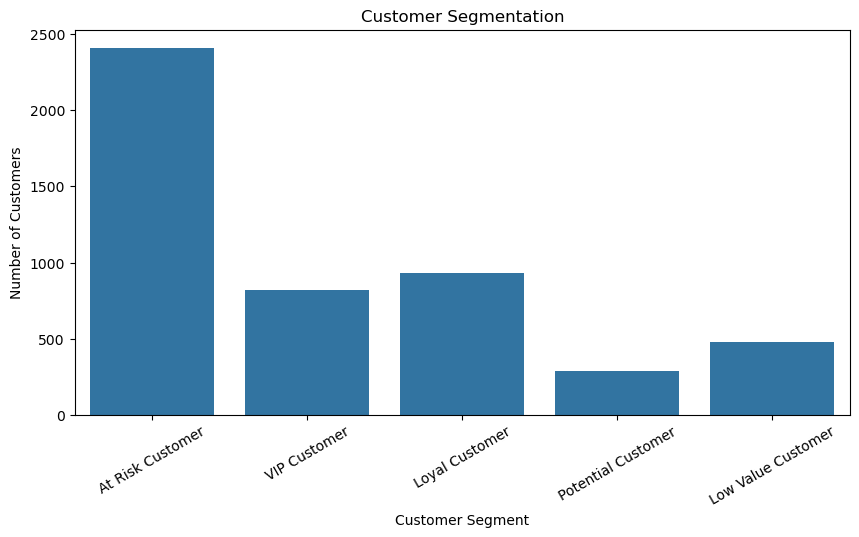

In [55]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=customer_df,
    x="customer_segment"
)

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30)

plt.show()

## Segment Profitability

In [57]:
segment_profit = (
    customer_df.groupby("customer_segment")
    .agg(
        customers=("customer_id", "count"),
        revenue=("total_revenue", "sum"),
        profit=("total_profit", "sum"),
        avg_clv=("total_profit", "mean"),
        avg_orders=("total_orders", "mean")
    )
    .sort_values("profit", ascending=False)
)

segment_profit

,customers,revenue,profit,avg_clv,avg_orders
customer_segment,,,,,
At Risk Customer,2408,2.118886e+08,77735217.27,32282.066973,3.024917
VIP Customer,820,1.938752e+08,71281243.63,86928.345890,6.729268
Loyal Customer,930,1.591875e+08,58869108.16,63300.116301,5.217204
Low Value Customer,479,3.514413e+07,12663256.98,26436.862171,2.954071
Potential Customer,287,2.345151e+07,8750319.31,30488.917456,3.243902


## Customer Cost Breakdown

In [59]:
profitability = customer_df[
    [
        "customer_id",
        "total_revenue",
        "total_profit",
        "total_discount",
        "total_shipping_cost",
        "total_marketing_cost",
        "total_return_cost",
        "total_returns"
    ]
].copy()

profitability.head()

,customer_id,total_revenue,total_profit,total_discount,total_shipping_cost,total_marketing_cost,total_return_cost,total_returns
0,CUST_00001,179435.1234,69138.82,56574.1766,1239.13,1620.36,3775.06,1
1,CUST_00002,19942.4568,6521.34,7535.0332,970.26,569.59,0.00,0
2,CUST_00003,80470.8576,19204.55,15327.7824,264.84,105.83,14351.04,1
3,CUST_00004,245089.3898,78490.58,61025.0802,1811.25,1334.32,0.00,0
4,CUST_00005,34991.1408,6616.24,4771.5192,278.41,89.42,6957.57,1


## Total Customer Cost

In [61]:
profitability["total_cost"] = (
    profitability["total_discount"]
    + profitability["total_shipping_cost"]
    + profitability["total_marketing_cost"]
    + profitability["total_return_cost"]
)

In [62]:
profitability[
    [
        "customer_id",
        "total_revenue",
        "total_cost",
        "total_profit"
    ]
].head(10)

,customer_id,total_revenue,total_cost,total_profit
0,CUST_00001,179435.1234,63208.7266,69138.82
1,CUST_00002,19942.4568,9074.8832,6521.34
2,CUST_00003,80470.8576,30049.4924,19204.55
3,CUST_00004,245089.3898,64170.6502,78490.58
4,CUST_00005,34991.1408,12096.9192,6616.24
5,CUST_00006,169570.7284,22820.5116,75769.42
6,CUST_00007,144123.9512,37094.9688,33880.64
7,CUST_00008,316965.1964,92448.4136,126688.14
8,CUST_00009,25478.9571,11059.7129,11182.20
9,CUST_00010,133066.0145,24187.0755,42372.59


## Profit Margin

In [64]:
profitability["profit_margin"] = (
    profitability["total_profit"]
    / profitability["total_revenue"]
) * 100

In [65]:
profitability[
    [
        "customer_id",
        "total_revenue",
        "total_profit",
        "profit_margin"
    ]
].head(10)

,customer_id,total_revenue,total_profit,profit_margin
0,CUST_00001,179435.1234,69138.82,38.531375
1,CUST_00002,19942.4568,6521.34,32.700785
2,CUST_00003,80470.8576,19204.55,23.865223
3,CUST_00004,245089.3898,78490.58,32.025287
4,CUST_00005,34991.1408,6616.24,18.908329
5,CUST_00006,169570.7284,75769.42,44.683078
6,CUST_00007,144123.9512,33880.64,23.507987
7,CUST_00008,316965.1964,126688.14,39.969101
8,CUST_00009,25478.9571,11182.20,43.887982
9,CUST_00010,133066.0145,42372.59,31.843285


## High Revenue but Low Profit

In [67]:
revenue_median = profitability["total_revenue"].median()

In [68]:
margin_median = profitability["profit_margin"].median()

In [69]:
profitability["business_risk"] = np.where(
    (profitability["total_revenue"] > revenue_median) &
    (profitability["profit_margin"] < margin_median),
    "High Revenue - Low Profit",
    "Normal"
)

In [70]:
profitability["business_risk"].value_counts()

business_risk
Normal                       3780
High Revenue - Low Profit    1144
Name: count, dtype: int64

## Top Revenue Customers

In [72]:
top_revenue_customers = profitability.sort_values(
    "total_revenue",
    ascending=False
).head(10)

top_revenue_customers[
    [
        "customer_id",
        "total_revenue",
        "total_profit",
        "profit_margin"
    ]
]

,customer_id,total_revenue,total_profit,profit_margin
3478,CUST_03535,534381.8137,177182.72,33.156577
3806,CUST_03866,529073.2412,172323.75,32.570869
3092,CUST_03148,514018.0962,197293.72,38.382641
3172,CUST_03229,487196.5825,202296.06,41.522471
3984,CUST_04045,466399.9435,166387.15,35.674779
3723,CUST_03782,453687.0894,167250.86,36.864805
162,CUST_00165,441873.4436,178175.32,40.322704
4851,CUST_04927,433408.6276,179943.55,41.518221
2377,CUST_02419,433092.2817,141606.44,32.696597
2469,CUST_02512,432041.4835,146577.55,33.926731


## Top Profit Customers

In [74]:
top_profit_customers = profitability.sort_values(
    "total_profit",
    ascending=False
).head(10)

top_profit_customers[
    [
        "customer_id",
        "total_revenue",
        "total_profit",
        "profit_margin"
    ]
]

,customer_id,total_revenue,total_profit,profit_margin
3172,CUST_03229,487196.5825,202296.06,41.522471
3092,CUST_03148,514018.0962,197293.72,38.382641
1517,CUST_01546,421080.8758,187039.10,44.418807
4851,CUST_04927,433408.6276,179943.55,41.518221
162,CUST_00165,441873.4436,178175.32,40.322704
3478,CUST_03535,534381.8137,177182.72,33.156577
3806,CUST_03866,529073.2412,172323.75,32.570869
2916,CUST_02968,398630.4850,170599.11,42.796303
3723,CUST_03782,453687.0894,167250.86,36.864805
3984,CUST_04045,466399.9435,166387.15,35.674779


## Revenue vs Profit Visualization

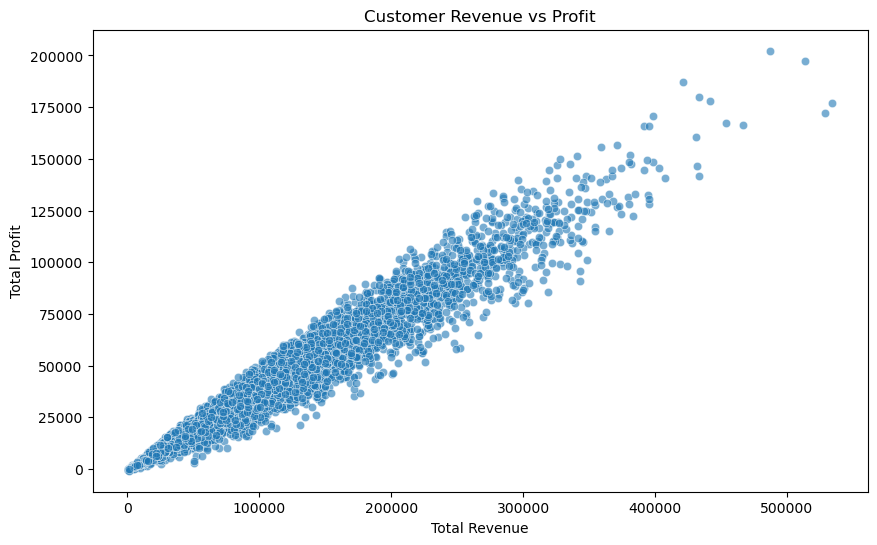

In [76]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=profitability,
    x="total_revenue",
    y="total_profit",
    alpha=0.6
)

plt.title("Customer Revenue vs Profit")
plt.xlabel("Total Revenue")
plt.ylabel("Total Profit")

plt.show()

## Profitability Categories

In [78]:
def profitability_category(margin):

    if margin >= 30:
        return "Highly Profitable"

    elif margin >= 15:
        return "Profitable"

    elif margin >= 0:
        return "Low Profit"

    else:
        return "Loss Making"

In [79]:
profitability["profitability_category"] = (
    profitability["profit_margin"]
    .apply(profitability_category)
)

In [80]:
profitability["profitability_category"].value_counts()

profitability_category
Highly Profitable    4129
Profitable            748
Low Profit             34
Loss Making            13
Name: count, dtype: int64

## Average Order Value

In [84]:
customer_df[
    [
        "customer_id",
        "avg_order_value"
    ]
].head()

,customer_id,avg_order_value
0,CUST_00001,29905.853900
1,CUST_00002,6647.485600
2,CUST_00003,80470.857600
3,CUST_00004,35012.769971
4,CUST_00005,34991.140800


## Purchase Frequency

In [86]:
customer_df["annual_purchase_frequency"] = (
    customer_df["total_orders"]
    / (customer_df["customer_tenure_months"] / 12)
)

## Expected Customer Lifespan

In [88]:
customer_df["expected_lifespan_years"] = (
    customer_df["customer_tenure_months"] / 12
)

In [90]:
customer_df["expected_lifespan_years"]

0       1.000000
1       1.000000
2       4.250000
3       4.666667
4       1.666667
          ...   
4919    4.083333
4920    2.166667
4921    4.250000
4922    3.416667
4923    3.916667
Name: expected_lifespan_years, Length: 4924, dtype: float64

In [91]:
customer_df["expected_lifespan_years"] = np.maximum(
    customer_df["expected_lifespan_years"],
    1
)

In [92]:
customer_df["expected_lifespan_years"]

0       1.000000
1       1.000000
2       4.250000
3       4.666667
4       1.666667
          ...   
4919    4.083333
4920    2.166667
4921    4.250000
4922    3.416667
4923    3.916667
Name: expected_lifespan_years, Length: 4924, dtype: float64

## CLV Calculate

In [94]:
customer_df["predicted_clv"] = (
    customer_df["avg_order_value"]
    * customer_df["annual_purchase_frequency"]
    * customer_df["expected_lifespan_years"]
    * (customer_df["profit_margin"] / 100)
)

In [95]:
customer_df[
    [
        "customer_id",
        "avg_order_value",
        "annual_purchase_frequency",
        "expected_lifespan_years",
        "profit_margin",
        "predicted_clv"
    ]
].head(10)

,customer_id,avg_order_value,annual_purchase_frequency,expected_lifespan_years,profit_margin,predicted_clv
0,CUST_00001,29905.853900,14.400000,1.000000,38.531375,165933.168
1,CUST_00002,6647.485600,18.000000,1.000000,32.700785,39128.040
2,CUST_00003,80470.857600,0.235294,4.250000,23.865223,19204.550
3,CUST_00004,35012.769971,1.500000,4.666667,32.025287,78490.580
4,CUST_00005,34991.140800,0.600000,1.666667,18.908329,6616.240
5,CUST_00006,56523.576133,1.058824,2.833333,44.683078,75769.420
6,CUST_00007,36030.987800,1.411765,2.833333,23.507987,33880.640
7,CUST_00008,39620.649550,1.777778,4.500000,39.969101,126688.140
8,CUST_00009,8492.985700,0.642857,4.666667,43.887982,11182.200
9,CUST_00010,33266.503625,0.872727,4.583333,31.843285,42372.590


## Top CLV Customers

In [97]:
top_clv = customer_df.sort_values(
    "predicted_clv",
    ascending=False
).head(10)

top_clv[
    [
        "customer_id",
        "total_orders",
        "total_revenue",
        "total_profit",
        "profit_margin",
        "predicted_clv"
    ]
]

,customer_id,total_orders,total_revenue,total_profit,profit_margin,predicted_clv
4532,CUST_04603,6,276772.0064,133594.60,48.268827,1603135.20
4052,CUST_04115,6,294896.3215,126226.70,42.803755,1514720.40
255,CUST_00259,7,251940.8401,106523.35,42.281097,1278280.20
2914,CUST_02966,6,282152.9121,100986.94,35.791564,1211843.28
2262,CUST_02303,7,261516.4456,100273.89,38.343244,1203286.68
2557,CUST_02603,5,270790.0645,100157.38,36.987096,1201888.56
3092,CUST_03148,9,514018.0962,197293.72,38.382641,1183762.32
1008,CUST_01023,4,212814.7766,95781.46,45.006959,1149377.52
1471,CUST_01499,6,240984.2501,92187.30,38.254492,1106247.60
502,CUST_00507,4,224822.9178,75823.96,33.726081,909887.52


## Company-Level Insight

In [99]:
print("Total Historical Profit:",
      customer_df["total_profit"].sum())

print("Total Estimated CLV:",
      customer_df["predicted_clv"].sum())

print("Average Customer CLV:",
      customer_df["predicted_clv"].mean())

Total Historical Profit: 229299145.35
Total Estimated CLV: 323467039.4062251
Average Customer CLV: 65691.92514342508


## Cutoff Date

In [101]:
cutoff_date = pd.Timestamp("2025-12-31")

future_start = pd.Timestamp("2026-01-01")
future_end = pd.Timestamp("2026-06-30")

## Past Customer Data

In [103]:
past_df = df[
    df["order_date"] <= cutoff_date
].copy()

past_df.shape

(16011, 23)

In [104]:
past_df["order_date"].min(), past_df["order_date"].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

## Future Data

In [106]:
future_df = df[
    (df["order_date"] >= future_start) &
    (df["order_date"] <= future_end)
].copy()

future_df.shape

(3989, 23)

In [107]:
future_df["order_date"].min(), future_df["order_date"].max()

(Timestamp('2026-01-01 00:00:00'), Timestamp('2026-06-30 00:00:00'))

## Create Future Profit Target

In [109]:
future_profit = (
    future_df.groupby("customer_id")
    ["profit"]
    .sum()
    .reset_index()
)

future_profit.columns = [
    "customer_id",
    "future_6m_profit"
]

future_profit.head()

,customer_id,future_6m_profit
0,CUST_00002,4054.28
1,CUST_00004,51386.93
2,CUST_00006,43628.91
3,CUST_00007,18558.94
4,CUST_00008,19843.84


In [110]:
future_profit_dataset = customer_df[
    ["customer_id"]
].merge(
    future_profit,
    on="customer_id",
    how="left"
)

In [111]:
future_profit_dataset["future_6m_profit"] = (
    future_profit_dataset["future_6m_profit"]
    .fillna(0)
)

In [112]:
future_profit_dataset.head(10)

,customer_id,future_6m_profit
0,CUST_00001,0.00
1,CUST_00002,4054.28
2,CUST_00003,0.00
3,CUST_00004,51386.93
4,CUST_00005,0.00
5,CUST_00006,43628.91
6,CUST_00007,18558.94
7,CUST_00008,19843.84
8,CUST_00009,0.00
9,CUST_00010,0.00


## Past Features Creation

In [114]:
past_customer = past_df.groupby("customer_id").agg(
    past_orders=("order_id", "count"),
    past_revenue=("total_amount", "sum"),
    past_profit=("profit", "sum"),
    past_discount=("discount_amount", "sum"),
    past_shipping_cost=("shipping_cost", "sum"),
    past_marketing_cost=("marketing_cost", "sum"),
    past_return_cost=("return_cost", "sum"),
    past_returns=("returned", "sum"),
    past_quantity=("quantity", "sum"),
    past_avg_order_value=("total_amount", "mean"),
    past_avg_satisfaction=("satisfaction_score", "mean")
).reset_index()

## Past Return Rate

In [116]:
past_customer["past_return_rate"] = (
    past_customer["past_returns"]
    / past_customer["past_orders"]
)

## Past Profit Margin

In [118]:
past_customer["past_profit_margin"] = (
    past_customer["past_profit"]
    / past_customer["past_revenue"]
)

## Past Recency

In [120]:
last_purchase = (
    past_df.groupby("customer_id")["order_date"]
    .max()
    .reset_index()
)

last_purchase.columns = [
    "customer_id",
    "last_purchase_date"
]

past_customer = past_customer.merge(
    last_purchase,
    on="customer_id",
    how="left"
)

In [5]:
past_customer["past_recency_days"] = (
    cutoff_date -
    past_customer["last_purchase_date"]
).dt.days

NameError: name 'cutoff_date' is not defined

## ML Dataset

In [4]:
ml_df = past_customer.merge(
    future_profit_dataset,
    on="customer_id",
    how="left"
)

NameError: name 'past_customer' is not defined

In [124]:
ml_df.head()

,customer_id,past_orders,past_revenue,past_profit,past_discount,past_shipping_cost,past_marketing_cost,past_return_cost,past_returns,past_quantity,past_avg_order_value,past_avg_satisfaction,past_return_rate,past_profit_margin,last_purchase_date,past_recency_days,future_6m_profit
0,CUST_00001,6,179435.1234,69138.82,56574.1766,1239.13,1620.36,3775.06,1,21,29905.85390,2.666667,0.166667,0.385314,2025-06-20,194,0.00
1,CUST_00002,2,11320.7572,2467.06,3477.7628,494.00,425.05,0.00,0,3,5660.37860,3.500000,0.000000,0.217924,2025-05-13,232,4054.28
2,CUST_00003,1,80470.8576,19204.55,15327.7824,264.84,105.83,14351.04,1,4,80470.85760,1.000000,1.000000,0.238652,2024-10-24,433,0.00
3,CUST_00004,4,92985.9242,27103.65,13452.9658,915.73,506.98,0.00,0,14,23246.48105,3.000000,0.000000,0.291481,2025-12-15,16,51386.93
4,CUST_00005,1,34991.1408,6616.24,4771.5192,278.41,89.42,6957.57,1,2,34991.14080,5.000000,1.000000,0.189083,2024-12-23,373,0.00


In [125]:
ml_df.shape

(4819, 17)

In [126]:
ml_df.isnull().sum()

customer_id              0
past_orders              0
past_revenue             0
past_profit              0
past_discount            0
past_shipping_cost       0
past_marketing_cost      0
past_return_cost         0
past_returns             0
past_quantity            0
past_avg_order_value     0
past_avg_satisfaction    0
past_return_rate         0
past_profit_margin       0
last_purchase_date       0
past_recency_days        0
future_6m_profit         0
dtype: int64

In [127]:
ml_df["future_6m_profit"].describe()

count      4819.000000
mean       9337.687134
std       13947.790206
min        -710.650000
25%           0.000000
50%        1783.470000
75%       14590.850000
max      108807.690000
Name: future_6m_profit, dtype: float64

In [128]:
ml_df[
    [
        "past_orders",
        "past_revenue",
        "past_profit",
        "past_return_rate",
        "past_recency_days",
        "future_6m_profit"
    ]
].describe()

,past_orders,past_revenue,past_profit,past_return_rate,past_recency_days,future_6m_profit
count,4819.000000,4819.000000,4819.000000,4819.000000,4819.000000,4819.000000
mean,3.322474,103241.332067,37953.945615,0.119707,199.647645,9337.687134
std,1.703224,70649.683596,27228.152811,0.209429,169.609525,13947.790206
min,1.000000,195.070200,-866.740000,0.000000,0.000000,-710.650000
25%,2.000000,49717.550100,17253.235000,0.000000,65.500000,0.000000
50%,3.000000,91186.981500,32980.150000,0.000000,150.000000,1783.470000
75%,4.000000,142510.762950,52699.245000,0.200000,293.000000,14590.850000
max,12.000000,529073.241200,172323.750000,1.000000,730.000000,108807.690000


## Features Select

In [130]:
features = [
    "past_orders",
    "past_revenue",
    "past_profit",
    "past_discount",
    "past_shipping_cost",
    "past_marketing_cost",
    "past_return_cost",
    "past_returns",
    "past_quantity",
    "past_avg_order_value",
    "past_avg_satisfaction",
    "past_return_rate",
    "past_profit_margin",
    "past_recency_days"
]

X = ml_df[features]

y = ml_df["future_6m_profit"]

In [131]:
X.head()

,past_orders,past_revenue,past_profit,past_discount,past_shipping_cost,past_marketing_cost,past_return_cost,past_returns,past_quantity,past_avg_order_value,past_avg_satisfaction,past_return_rate,past_profit_margin,past_recency_days
0,6,179435.1234,69138.82,56574.1766,1239.13,1620.36,3775.06,1,21,29905.85390,2.666667,0.166667,0.385314,194
1,2,11320.7572,2467.06,3477.7628,494.00,425.05,0.00,0,3,5660.37860,3.500000,0.000000,0.217924,232
2,1,80470.8576,19204.55,15327.7824,264.84,105.83,14351.04,1,4,80470.85760,1.000000,1.000000,0.238652,433
3,4,92985.9242,27103.65,13452.9658,915.73,506.98,0.00,0,14,23246.48105,3.000000,0.000000,0.291481,16
4,1,34991.1408,6616.24,4771.5192,278.41,89.42,6957.57,1,2,34991.14080,5.000000,1.000000,0.189083,373


In [132]:
y.head()

0        0.00
1     4054.28
2        0.00
3    51386.93
4        0.00
Name: future_6m_profit, dtype: float64

## Train/Test Split

In [134]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## Model

In [137]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=12, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, n_jobs=-1, random_state=42)

## Prediction

In [139]:
y_pred = model.predict(X_test)

## Evaluation

In [141]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 10818.25130136435
RMSE: 14077.608376557442
R² Score: -0.018104800575577062


## Actual vs Predicted

In [143]:
prediction_df = pd.DataFrame({
    "Actual_Profit": y_test.values,
    "Predicted_Profit": y_pred
})

prediction_df.head(10)

,Actual_Profit,Predicted_Profit
0,0.00,8683.477924
1,17887.41,8957.341239
2,28836.66,11634.307089
3,0.00,9378.241673
4,13856.77,7435.483510
5,0.00,8223.819099
6,0.00,11198.392056
7,18385.04,8254.762766
8,0.00,8939.949265
9,0.00,13919.137754


## Final Customer Predictions

In [145]:
ml_df["predicted_future_profit"] = model.predict(
    ml_df[features]
)

In [146]:
top_future_customers = ml_df.sort_values(
    "predicted_future_profit",
    ascending=False
).head(20)

top_future_customers[
    [
        "customer_id",
        "past_revenue",
        "past_profit",
        "future_6m_profit",
        "predicted_future_profit"
    ]
]

,customer_id,past_revenue,past_profit,future_6m_profit,predicted_future_profit
2150,CUST_02242,80035.9315,35621.57,108807.69,39784.615928
3643,CUST_03782,243769.0965,85727.98,81522.88,33714.505126
3284,CUST_03412,261250.6100,83375.55,49645.06,33483.871267
4668,CUST_04842,9837.8280,2415.63,86771.24,33456.042346
2998,CUST_03122,89943.8280,46312.58,67131.69,31212.841415
2356,CUST_02452,87246.7642,13969.50,50588.62,30740.738799
4520,CUST_04686,2160.0730,397.19,47422.81,29704.355767
2889,CUST_03007,86887.4440,29932.30,34352.68,29256.873780
3675,CUST_03815,12834.1560,3685.99,51942.16,28094.784810
942,CUST_00985,90398.0608,20384.41,75264.85,27739.122886


## Feature Importance

In [250]:
feature_importance = pd.DataFrame({
    "feature": features,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
3,past_discount,0.121819
4,past_shipping_cost,0.117757
12,past_profit_margin,0.117106
5,past_marketing_cost,0.112980
9,past_avg_order_value,0.107596
13,past_recency_days,0.103062
1,past_revenue,0.078516
2,past_profit,0.073801
10,past_avg_satisfaction,0.063950
8,past_quantity,0.044317


## Visualize

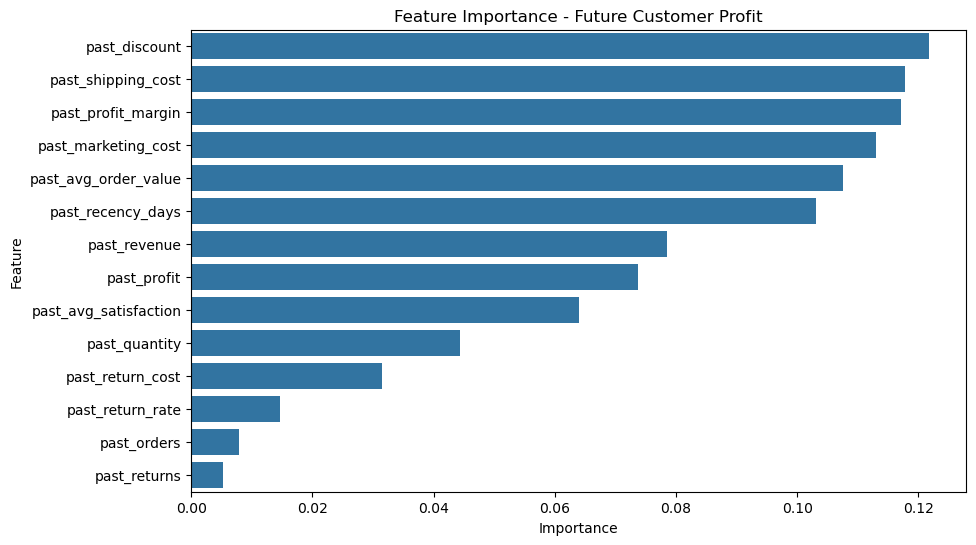

In [150]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)

plt.title("Feature Importance - Future Customer Profit")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Predicted Customer Value Segments

In [152]:
def future_value_segment(value):

    if value >= ml_df["predicted_future_profit"].quantile(0.80):
        return "High Future Value"

    elif value >= ml_df["predicted_future_profit"].quantile(0.50):
        return "Medium Future Value"

    elif value > 0:
        return "Low Future Value"

    else:
        return "Future Loss Risk"

In [153]:
ml_df["future_value_segment"] = (
    ml_df["predicted_future_profit"]
    .apply(future_value_segment)
)

In [154]:
ml_df["future_value_segment"].value_counts()

future_value_segment
Low Future Value       2409
Medium Future Value    1446
High Future Value       964
Name: count, dtype: int64

## Business Summary

In [2]:
future_segment_summary = (
    ml_df.groupby("future_value_segment")
    .agg(
        customers=("customer_id", "count"),
        predicted_profit=("predicted_future_profit", "sum"),
        historical_profit=("past_profit", "sum")
    )
    .sort_values(
        "predicted_profit",
        ascending=False
    )
)

future_segment_summary

NameError: name 'ml_df' is not defined

## Final Customer Intelligence Table

In [158]:
final_customer_data = customer_df.merge(
    ml_df[
        [
            "customer_id",
            "predicted_future_profit",
            "future_value_segment"
        ]
    ],
    on="customer_id",
    how="left"
)

In [159]:
final_customer_data[
    [
        "customer_id",
        "customer_segment",
        "total_revenue",
        "total_profit",
        "profit_margin",
        "recency_days",
        "total_orders",
        "predicted_clv",
        "predicted_future_profit",
        "future_value_segment"
    ]
].head(10)

,customer_id,customer_segment,total_revenue,total_profit,profit_margin,recency_days,total_orders,predicted_clv,predicted_future_profit,future_value_segment
0,CUST_00001,At Risk Customer,179435.1234,69138.82,38.531375,375,6,165933.168,6212.505731,Low Future Value
1,CUST_00002,At Risk Customer,19942.4568,6521.34,32.700785,166,3,39128.040,6426.667304,Low Future Value
2,CUST_00003,At Risk Customer,80470.8576,19204.55,23.865223,614,1,19204.550,6511.035831,Low Future Value
3,CUST_00004,VIP Customer,245089.3898,78490.58,32.025287,74,7,78490.580,15495.297910,High Future Value
4,CUST_00005,At Risk Customer,34991.1408,6616.24,18.908329,554,1,6616.240,7669.156293,Low Future Value
5,CUST_00006,Loyal Customer,169570.7284,75769.42,44.683078,27,3,75769.420,18294.196664,High Future Value
6,CUST_00007,At Risk Customer,144123.9512,33880.64,23.507987,152,4,33880.640,9405.027877,Medium Future Value
7,CUST_00008,VIP Customer,316965.1964,126688.14,39.969101,96,8,126688.140,12571.351607,High Future Value
8,CUST_00009,At Risk Customer,25478.9571,11182.20,43.887982,298,3,11182.200,8939.949265,Medium Future Value
9,CUST_00010,At Risk Customer,133066.0145,42372.59,31.843285,403,4,42372.590,7028.941509,Low Future Value


 ## Decision Score

In [161]:
final_customer_data["decision"] = "Monitor"

## Business Rules

In [163]:
def business_decision(row):

    if (
        row["predicted_future_profit"] > 0
        and row["profit_margin"] >= 20
        and row["recency_days"] <= 60
    ):
        return "Retain & Upsell"

    elif (
        row["total_revenue"] > final_customer_data["total_revenue"].median()
        and row["profit_margin"] < 10
    ):
        return "Reduce Cost"

    elif (
        row["recency_days"] > 120
        and row["predicted_future_profit"] > 0
    ):
        return "Retention Campaign"

    elif (
        row["profit_margin"] < 0
    ):
        return "Loss Risk"

    elif (
        row["predicted_future_profit"] > 0
        and row["total_orders"] >= 5
    ):
        return "Growth Opportunity"

    else:
        return "Monitor"

In [164]:
final_customer_data["business_decision"] = (
    final_customer_data.apply(
        business_decision,
        axis=1
    )
)

## Decision Distribution

In [166]:
final_customer_data[
    "business_decision"
].value_counts()

business_decision
Retention Campaign    2852
Retain & Upsell       1126
Monitor                504
Growth Opportunity     439
Loss Risk                3
Name: count, dtype: int64

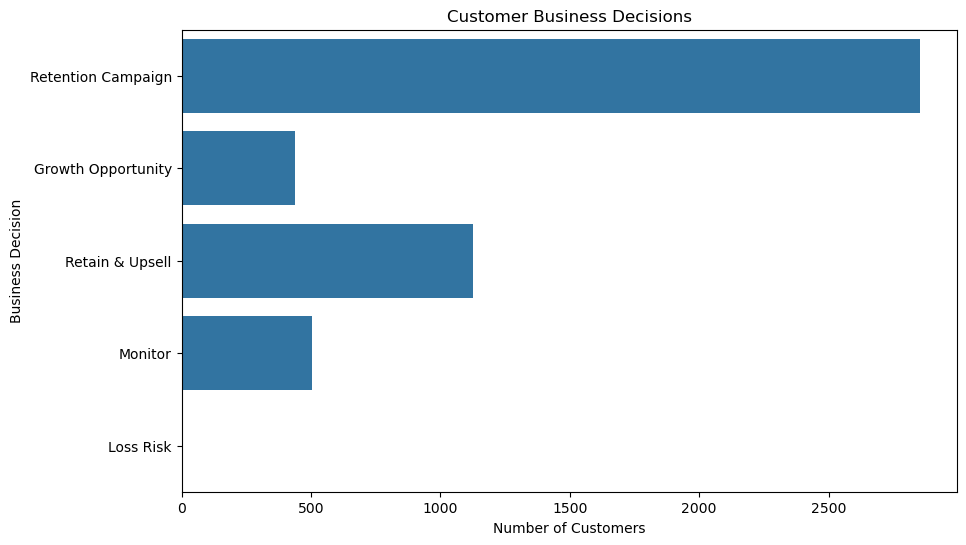

In [167]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=final_customer_data,
    y="business_decision"
)

plt.title("Customer Business Decisions")
plt.xlabel("Number of Customers")
plt.ylabel("Business Decision")

plt.show()

## Decision-Level Profitability

In [169]:
decision_summary = (
    final_customer_data
    .groupby("business_decision")
    .agg(
        customers=("customer_id", "count"),
        revenue=("total_revenue", "sum"),
        historical_profit=("total_profit", "sum"),
        predicted_future_profit=(
            "predicted_future_profit",
            "sum"
        )
    )
    .sort_values(
        "predicted_future_profit",
        ascending=False
    )
)

decision_summary

,customers,revenue,historical_profit,predicted_future_profit
business_decision,,,,
Retention Campaign,2852,3.161298e+08,1.163237e+08,2.366581e+07
Retain & Upsell,1126,1.751896e+08,6.449930e+07,1.240338e+07
Growth Opportunity,439,8.616132e+07,3.147854e+07,4.590574e+06
Monitor,504,4.605929e+07,1.699817e+07,4.188911e+06
Loss Risk,3,6.875905e+03,-6.106500e+02,0.000000e+00


## Final Business Matrix

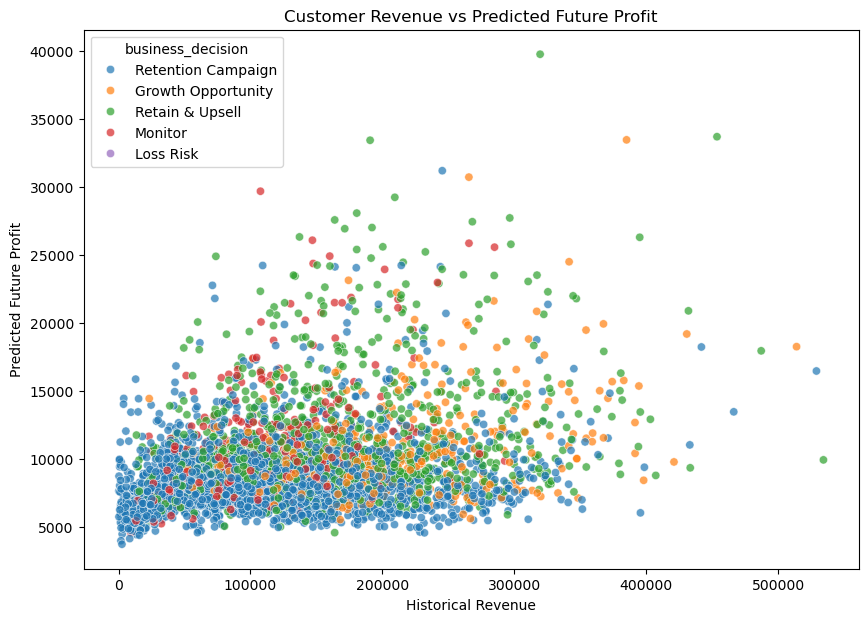

In [171]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=final_customer_data,
    x="total_revenue",
    y="predicted_future_profit",
    hue="business_decision",
    alpha=0.7
)

plt.title(
    "Customer Revenue vs Predicted Future Profit"
)

plt.xlabel("Historical Revenue")
plt.ylabel("Predicted Future Profit")

plt.show()

In [176]:
## Final Dataset

In [177]:
final_customer_data.to_csv(
    "customer_lifetime_value_final.csv",
    index=False
)

print("Final customer dataset saved successfully!")

Final customer dataset saved successfully!


## Model Validation

In [179]:
X = ml_df[features]
y = ml_df["future_6m_profit"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

model.fit(X_train,y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Evaluation
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test,y_pred)

print("FINAL MODEL PERFORMANCE")
print("-----------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

FINAL MODEL PERFORMANCE
-----------------------
MAE: 10818.251301364351
RMSE: 14077.608376557442
R² Score: -0.018104800575577062


In [180]:
prediction_df = pd.DataFrame({
    "Actual_Profit": y_test.values,
    "Predicted_Profit": y_pred
})

prediction_df["Error"] = (
    prediction_df["Actual_Profit"]
    - prediction_df["Predicted_Profit"]
)

prediction_df["Absolute_Error"] = (
    prediction_df["Error"].abs()
)

prediction_df.head(10)

,Actual_Profit,Predicted_Profit,Error,Absolute_Error
0,0.00,8683.477924,-8683.477924,8683.477924
1,17887.41,8957.341239,8930.068761,8930.068761
2,28836.66,11634.307089,17202.352911,17202.352911
3,0.00,9378.241673,-9378.241673,9378.241673
4,13856.77,7435.483510,6421.286490,6421.286490
5,0.00,8223.819099,-8223.819099,8223.819099
6,0.00,11198.392056,-11198.392056,11198.392056
7,18385.04,8254.762766,10130.277234,10130.277234
8,0.00,8939.949265,-8939.949265,8939.949265
9,0.00,13919.137754,-13919.137754,13919.137754


In [181]:
prediction_df.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual_Profit,Predicted_Profit,Error,Absolute_Error
649,76857.61,7495.892530,69361.717470,69361.717470
650,76075.72,8575.452058,67500.267942,67500.267942
822,76324.43,9209.398925,67115.031075,67115.031075
246,65116.58,8870.095639,56246.484361,56246.484361
802,62579.85,7731.908795,54847.941205,54847.941205
713,64967.45,10241.577138,54725.872862,54725.872862
238,63271.26,8599.493298,54671.766702,54671.766702
677,62818.49,8748.198470,54070.291530,54070.291530
500,62096.14,9784.705787,52311.434213,52311.434213
680,59266.98,8430.033340,50836.946660,50836.946660


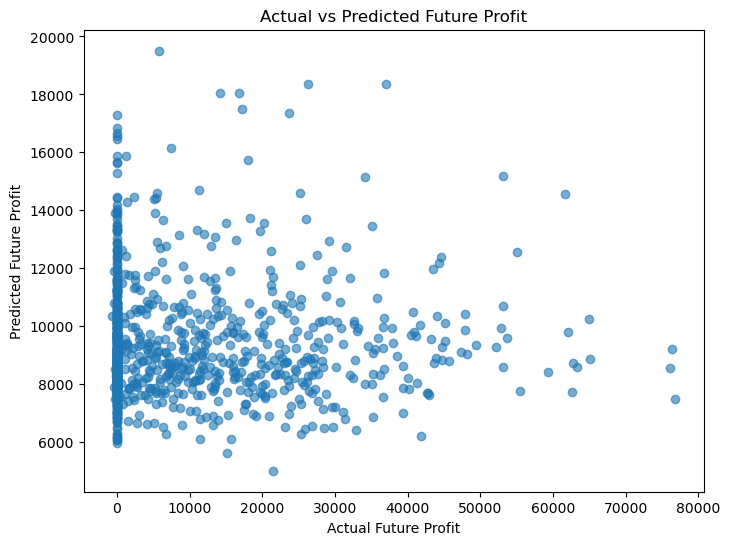

In [182]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.xlabel("Actual Future Profit")
plt.ylabel("Predicted Future Profit")
plt.title("Actual vs Predicted Future Profit")

plt.show()

## Improved Realistic Dataset

In [184]:
import pandas as pd
import numpy as np

np.random.seed(42)

n_customers = 5000
n_orders = 30000

customer_ids = [
    f"CUST_{i:05d}"
    for i in range(1, n_customers + 1)
]

customers = pd.DataFrame({
    "customer_id": customer_ids,

    "customer_age": np.random.randint(
        18, 65, n_customers
    ),

    "customer_gender": np.random.choice(
        ["Male", "Female", "Other"],
        n_customers,
        p=[0.48, 0.49, 0.03]
    ),

    "region": np.random.choice(
        ["North", "South", "East", "West", "Central"],
        n_customers
    ),

    "customer_tenure_months": np.random.randint(
        12, 61, n_customers
    )
})

In [185]:
customers["customer_value"] = np.random.lognormal(
    mean=0,
    sigma=0.55,
    size=n_customers
)

customers["purchase_propensity"] = np.random.beta(
    2.5,
    2.5,
    n_customers
)

customers["return_propensity"] = np.random.beta(
    1.5,
    12,
    n_customers
)

customers["discount_sensitivity"] = np.random.beta(
    2,
    5,
    n_customers
)

In [186]:
orders = []

start_date = pd.Timestamp("2024-01-01")
end_date = pd.Timestamp("2026-06-30")

categories = [
    "Electronics",
    "Fashion",
    "Home",
    "Grocery",
    "Beauty",
    "Sports"
]

for customer in customers.itertuples():

    # Customer-specific order count
    expected_orders = (
        2
        + customer.purchase_propensity * 12
        + customer.customer_value * 2
    )

    order_count = max(
        1,
        np.random.poisson(expected_orders)
    )

    for _ in range(order_count):

        order_date = (
            start_date
            + pd.Timedelta(
                days=np.random.randint(
                    0,
                    (end_date - start_date).days + 1
                )
            )
        )

        base_price = (
            500
            + customer.customer_value
            * np.random.uniform(1000, 5000)
        )

        quantity = np.random.randint(1, 5)

        discount = np.clip(
            np.random.normal(
                0.10
                + customer.discount_sensitivity * 0.15,
                0.04
            ),
            0,
            0.35
        )

        gross_amount = (
            base_price * quantity
        )

        discount_amount = (
            gross_amount * discount
        )

        total_amount = (
            gross_amount - discount_amount
        )

        product_cost = (
            total_amount
            * np.random.uniform(0.45, 0.70)
        )

        shipping_cost = np.random.uniform(
            40,
            450
        )

        returned = np.random.random() < (
            0.03
            + customer.return_propensity * 0.20
        )

        return_cost = (
            total_amount
            * np.random.uniform(0.05, 0.18)
            if returned
            else 0
        )

        marketing_cost = (
            30
            + (1 - customer.purchase_propensity)
            * np.random.uniform(50, 250)
        )

        profit = (
            total_amount
            - product_cost
            - shipping_cost
            - marketing_cost
            - return_cost
        )

        satisfaction = np.clip(
            4.5
            - (discount * 2)
            - (customer.return_propensity * 1.5)
            + np.random.normal(0, 0.35),
            1,
            5
        )

        orders.append({
            "customer_id": customer.customer_id,
            "order_date": order_date,
            "category": np.random.choice(categories),
            "quantity": quantity,
            "unit_price": base_price,
            "discount": discount,
            "discount_amount": discount_amount,
            "total_amount": total_amount,
            "product_cost": product_cost,
            "shipping_cost": shipping_cost,
            "marketing_cost": marketing_cost,
            "returned": int(returned),
            "return_cost": return_cost,
            "profit": profit,
            "satisfaction_score": satisfaction
        })

In [187]:
improved_df = pd.DataFrame(orders)

improved_df.insert(
    0,
    "order_id",
    [
        f"ORD_{i:06d}"
        for i in range(1, len(improved_df) + 1)
    ]
)

improved_df = improved_df.merge(
    customers[
        [
            "customer_id",
            "customer_age",
            "customer_gender",
            "region",
            "customer_tenure_months"
        ]
    ],
    on="customer_id",
    how="left"
)

improved_df = improved_df.sort_values(
    ["customer_id", "order_date"]
).reset_index(drop=True)

print("Rows:", len(improved_df))
print("Customers:", improved_df["customer_id"].nunique())
print("Columns:", len(improved_df.columns))

Rows: 51491
Customers: 5000
Columns: 20


In [188]:
improved_df.head()

,order_id,customer_id,order_date,category,quantity,unit_price,discount,discount_amount,total_amount,product_cost,shipping_cost,marketing_cost,returned,return_cost,profit,satisfaction_score,customer_age,customer_gender,region,customer_tenure_months
0,ORD_000005,CUST_00001,2024-01-20,Electronics,4,3411.515969,0.151989,2074.055168,11572.008710,7034.770986,436.422688,79.687277,0,0.0,4021.127759,5.000000,56,Female,East,16
1,ORD_000009,CUST_00001,2024-03-31,Electronics,4,1647.274467,0.148115,975.946412,5613.151455,3064.615330,398.837560,80.675451,0,0.0,2069.023115,3.014970,56,Female,East,16
2,ORD_000008,CUST_00001,2024-04-04,Beauty,2,3210.157778,0.098280,630.988444,5789.327112,3589.864183,358.237198,74.503948,0,0.0,1766.721782,4.542255,56,Female,East,16
3,ORD_000001,CUST_00001,2024-04-21,Home,4,2789.726245,0.212769,2374.265148,8784.639830,5790.441151,420.830227,103.597107,0,0.0,2469.771345,4.020620,56,Female,East,16
4,ORD_000004,CUST_00001,2025-01-25,Grocery,4,1308.205999,0.098699,516.474235,4716.349760,2250.466235,320.782298,55.345244,0,0.0,2089.755983,3.701702,56,Female,East,16


In [189]:
improved_df.isnull().sum()

order_id                  0
customer_id               0
order_date                0
category                  0
quantity                  0
unit_price                0
discount                  0
discount_amount           0
total_amount              0
product_cost              0
shipping_cost             0
marketing_cost            0
returned                  0
return_cost               0
profit                    0
satisfaction_score        0
customer_age              0
customer_gender           0
region                    0
customer_tenure_months    0
dtype: int64

In [190]:
improved_df.to_csv(
    "customer_lifetime_value_improved.csv",
    index=False
)

print("Improved dataset saved successfully!")

Improved dataset saved successfully!


In [191]:
customer_test = (
    improved_df
    .groupby("customer_id")
    .agg(
        orders=("order_id", "count"),
        revenue=("total_amount", "sum"),
        profit=("profit", "sum")
    )
    .reset_index()
)

customer_test.head()

,customer_id,orders,revenue,profit
0,CUST_00001,11,71237.733990,23878.252654
1,CUST_00002,13,51514.959253,15516.353365
2,CUST_00003,6,27021.641427,8771.224999
3,CUST_00004,10,113891.868127,47985.653373
4,CUST_00005,10,56412.873264,21698.530931


In [192]:
print("Rows:", len(improved_df))
print("Customers:", improved_df["customer_id"].nunique())
print("Columns:", len(improved_df.columns))

Rows: 51491
Customers: 5000
Columns: 20


In [194]:
cutoff_date = pd.Timestamp("2025-12-31")

past_df = improved_df[
    improved_df["order_date"] <= cutoff_date
].copy()

future_df = improved_df[
    improved_df["order_date"] > cutoff_date
].copy()

print("Past rows:", len(past_df))
print("Future rows:", len(future_df))

Past rows: 41208
Future rows: 10283


In [195]:
future_profit = (
    future_df
    .groupby("customer_id")["profit"]
    .sum()
    .reset_index()
)

future_profit.columns = [
    "customer_id",
    "future_6m_profit"
]

future_profit.head()

,customer_id,future_6m_profit
0,CUST_00001,2623.411601
1,CUST_00002,2488.251928
2,CUST_00003,514.168221
3,CUST_00004,4998.924330
4,CUST_00005,9632.633051


In [196]:
past_customer = (
    past_df
    .groupby("customer_id")
    .agg(
        past_orders=("order_id", "count"),
        past_revenue=("total_amount", "sum"),
        past_profit=("profit", "sum"),
        past_discount=("discount_amount", "sum"),
        past_shipping_cost=("shipping_cost", "sum"),
        past_marketing_cost=("marketing_cost", "sum"),
        past_return_cost=("return_cost", "sum"),
        past_returns=("returned", "sum"),
        past_quantity=("quantity", "sum"),
        past_avg_order_value=("total_amount", "mean"),
        past_avg_satisfaction=("satisfaction_score", "mean")
    )
    .reset_index()
)

past_customer.head()

,customer_id,past_orders,past_revenue,past_profit,past_discount,past_shipping_cost,past_marketing_cost,past_return_cost,past_returns,past_quantity,past_avg_order_value,past_avg_satisfaction
0,CUST_00001,9,63768.803216,21254.841053,8845.857905,3327.217758,715.882350,0.000000,0,31,7085.422580,4.094197
1,CUST_00002,11,41675.848813,13028.101437,4795.761313,3660.064775,609.135238,386.403347,2,24,3788.713528,4.030134
2,CUST_00003,5,24796.429574,8257.056778,3183.351346,1022.468569,492.229745,0.000000,0,13,4959.285915,3.909129
3,CUST_00004,8,102257.799206,42986.729043,18492.398709,1382.154302,914.344102,855.700909,1,20,12782.224901,4.026633
4,CUST_00005,8,36552.376084,12065.897880,7900.210210,2555.684841,1018.483211,407.253082,1,15,4569.047011,4.206519


In [197]:
past_customer["past_return_rate"] = np.where(
    past_customer["past_orders"] > 0,
    past_customer["past_returns"] /
    past_customer["past_orders"],
    0
)

past_customer["past_profit_margin"] = np.where(
    past_customer["past_revenue"] > 0,
    past_customer["past_profit"] /
    past_customer["past_revenue"],
    0
)

In [198]:
last_purchase = (
    past_df
    .groupby("customer_id")["order_date"]
    .max()
    .reset_index()
)

last_purchase.columns = [
    "customer_id",
    "last_purchase_date"
]

past_customer = past_customer.merge(
    last_purchase,
    on="customer_id",
    how="left"
)

past_customer["past_recency_days"] = (
    cutoff_date -
    past_customer["last_purchase_date"]
).dt.days

In [199]:
ml_df_new = past_customer.merge(
    future_profit,
    on="customer_id",
    how="left"
)

ml_df_new["future_6m_profit"] = (
    ml_df_new["future_6m_profit"]
    .fillna(0)
)

print("ML Dataset Shape:", ml_df_new.shape)

ML Dataset Shape: (4991, 17)


In [200]:
ml_df_new.head()

,customer_id,past_orders,past_revenue,past_profit,past_discount,past_shipping_cost,past_marketing_cost,past_return_cost,past_returns,past_quantity,past_avg_order_value,past_avg_satisfaction,past_return_rate,past_profit_margin,last_purchase_date,past_recency_days,future_6m_profit
0,CUST_00001,9,63768.803216,21254.841053,8845.857905,3327.217758,715.882350,0.000000,0,31,7085.422580,4.094197,0.000000,0.333311,2025-11-06,55,2623.411601
1,CUST_00002,11,41675.848813,13028.101437,4795.761313,3660.064775,609.135238,386.403347,2,24,3788.713528,4.030134,0.181818,0.312606,2025-12-12,19,2488.251928
2,CUST_00003,5,24796.429574,8257.056778,3183.351346,1022.468569,492.229745,0.000000,0,13,4959.285915,3.909129,0.000000,0.332994,2025-02-07,327,514.168221
3,CUST_00004,8,102257.799206,42986.729043,18492.398709,1382.154302,914.344102,855.700909,1,20,12782.224901,4.026633,0.125000,0.420376,2025-06-25,189,4998.924330
4,CUST_00005,8,36552.376084,12065.897880,7900.210210,2555.684841,1018.483211,407.253082,1,15,4569.047011,4.206519,0.125000,0.330099,2025-10-12,80,9632.633051


In [201]:
features_new = [
    "past_orders",
    "past_revenue",
    "past_profit",
    "past_discount",
    "past_shipping_cost",
    "past_marketing_cost",
    "past_return_cost",
    "past_returns",
    "past_quantity",
    "past_avg_order_value",
    "past_avg_satisfaction",
    "past_return_rate",
    "past_profit_margin",
    "past_recency_days"
]

X_new = ml_df_new[features_new]
y_new = ml_df_new["future_6m_profit"]

In [202]:
from sklearn.model_selection import train_test_split

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new,
    y_new,
    test_size=0.20,
    random_state=42
)

In [203]:
from sklearn.ensemble import RandomForestRegressor

final_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train_new,
    y_train_new
)

RandomForestRegressor(max_depth=12, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [204]:
y_pred_new = final_model.predict(
    X_test_new
)

In [205]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_new = mean_absolute_error(
    y_test_new,
    y_pred_new
)

rmse_new = np.sqrt(
    mean_squared_error(
        y_test_new,
        y_pred_new
    )
)

r2_new = r2_score(
    y_test_new,
    y_pred_new
)

print("IMPROVED FINAL MODEL PERFORMANCE")
print("--------------------------------")
print("MAE:", mae_new)
print("RMSE:", rmse_new)
print("R² Score:", r2_new)

IMPROVED FINAL MODEL PERFORMANCE
--------------------------------
MAE: 5189.941890869818
RMSE: 7824.025375199174
R² Score: 0.4117707869294601


## Feature Importance

In [254]:
feature_importance_new = pd.DataFrame({
    "feature": features_new,
    "importance": final_model.feature_importances_
})

feature_importance_new = feature_importance_new.sort_values(
    "importance",
    ascending=False
)

feature_importance_new

,feature,importance
9,past_avg_order_value,0.328180
2,past_profit,0.156949
5,past_marketing_cost,0.090255
1,past_revenue,0.077568
3,past_discount,0.075038
10,past_avg_satisfaction,0.048854
13,past_recency_days,0.046477
12,past_profit_margin,0.044381
4,past_shipping_cost,0.040770
8,past_quantity,0.038729


## Graph

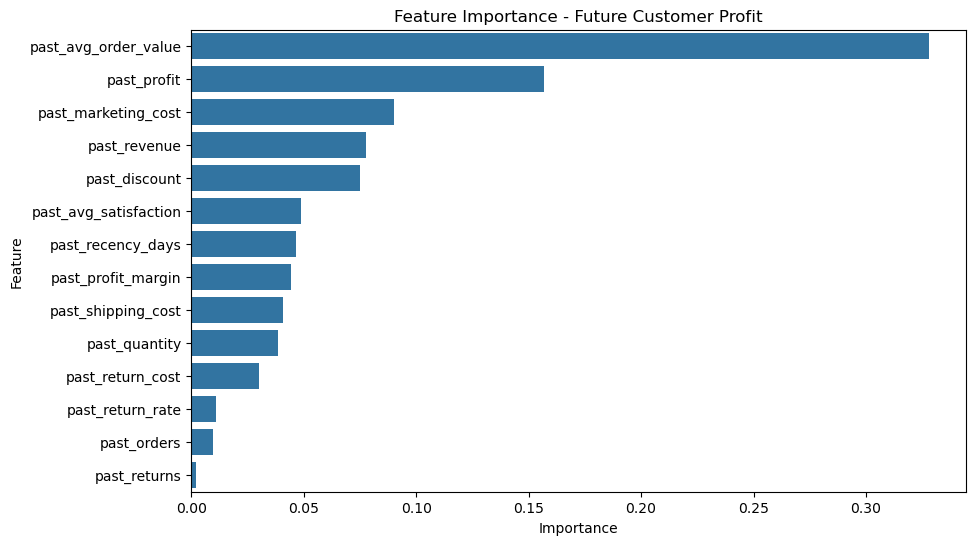

In [211]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance_new,
    x="importance",
    y="feature"
)

plt.title("Feature Importance - Future Customer Profit")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# Actual vs Predicted

In [213]:
prediction_df_new = pd.DataFrame({
    "Actual_Profit": y_test_new.values,
    "Predicted_Profit": y_pred_new
})

prediction_df_new["Error"] = (
    prediction_df_new["Actual_Profit"]
    - prediction_df_new["Predicted_Profit"]
)

prediction_df_new["Absolute_Error"] = (
    prediction_df_new["Error"].abs()
)

prediction_df_new.head(10)

,Actual_Profit,Predicted_Profit,Error,Absolute_Error
0,1103.460286,3642.113939,-2538.653653,2538.653653
1,15049.399939,1840.315484,13209.084456,13209.084456
2,5410.153257,5914.075624,-503.922367,503.922367
3,0.000000,7904.752628,-7904.752628,7904.752628
4,8541.672559,13296.721786,-4755.049227,4755.049227
5,0.000000,10036.336646,-10036.336646,10036.336646
6,3469.046480,4322.488848,-853.442368,853.442368
7,10338.436711,10910.502686,-572.065975,572.065975
8,5401.840230,5562.059381,-160.219151,160.219151
9,6153.970883,4933.745669,1220.225214,1220.225214


In [214]:
prediction_df_new.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual_Profit,Predicted_Profit,Error,Absolute_Error
94,95912.523943,32449.492158,63463.031784,63463.031784
556,60505.795401,13074.113142,47431.682259,47431.682259
218,3208.687765,45562.633721,-42353.945956,42353.945956
251,50145.397538,13967.746451,36177.651086,36177.651086
25,55782.067813,22648.715976,33133.351837,33133.351837
484,50084.368636,17162.812683,32921.555954,32921.555954
892,46754.719804,14211.529387,32543.190418,32543.190418
508,38141.691024,8516.818580,29624.872444,29624.872444
916,0.000000,29078.944189,-29078.944189,29078.944189
253,45404.239846,16422.368123,28981.871723,28981.871723


## Model Save

In [245]:
import joblib

joblib.dump(
    final_model,
    "customer_profit_final_model.pkl"
)

joblib.dump(
    features_new,
    "customer_profit_model_features.pkl"
)

print("Final model saved successfully!")
print("Feature list saved successfully!")

Final model saved successfully!
Feature list saved successfully!


## Prediction Function

In [218]:
def predict_customer_profit(
    past_orders,
    past_revenue,
    past_profit,
    past_discount,
    past_shipping_cost,
    past_marketing_cost,
    past_return_cost,
    past_returns,
    past_quantity,
    past_avg_order_value,
    past_avg_satisfaction,
    past_return_rate,
    past_profit_margin,
    past_recency_days
):

    customer = pd.DataFrame({
        "past_orders": [past_orders],
        "past_revenue": [past_revenue],
        "past_profit": [past_profit],
        "past_discount": [past_discount],
        "past_shipping_cost": [past_shipping_cost],
        "past_marketing_cost": [past_marketing_cost],
        "past_return_cost": [past_return_cost],
        "past_returns": [past_returns],
        "past_quantity": [past_quantity],
        "past_avg_order_value": [past_avg_order_value],
        "past_avg_satisfaction": [past_avg_satisfaction],
        "past_return_rate": [past_return_rate],
        "past_profit_margin": [past_profit_margin],
        "past_recency_days": [past_recency_days]
    })

    prediction = final_model.predict(
        customer[features_new]
    )[0]

    return prediction

## Test Customer

In [220]:
predicted_profit = predict_customer_profit(
    past_orders=12,
    past_revenue=65000,
    past_profit=12000,
    past_discount=5000,
    past_shipping_cost=1500,
    past_marketing_cost=800,
    past_return_cost=700,
    past_returns=1,
    past_quantity=25,
    past_avg_order_value=5416,
    past_avg_satisfaction=4.5,
    past_return_rate=8.33,
    past_profit_margin=18.46,
    past_recency_days=15
)

print(
    "Predicted Future 6-Month Profit:",
    predicted_profit
)

Predicted Future 6-Month Profit: 6183.446855319128


## Future Value Category

In [225]:
q80_new = ml_df_new["future_6m_profit"].quantile(0.80)
q50_new = ml_df_new["future_6m_profit"].quantile(0.50)

print("80th Percentile:", q80_new)
print("50th Percentile:", q50_new)

80th Percentile: 11305.539787117155
50th Percentile: 4399.689293767173


In [228]:
if predicted_profit >= q80_new:
    value_segment = "High Future Value"

elif predicted_profit >= q50_new:
    value_segment = "Medium Future Value"

elif predicted_profit > 0:
    value_segment = "Low Future Value"

else:
    value_segment = "Future Loss Risk"

print("Future Value:", value_segment)

Future Value: Medium Future Value


## Business Recommendation

In [224]:
if (
    predicted_profit > 0
    and 18.46 >= 20
    and 15 <= 60
):
    decision = "Retain & Upsell"

elif 15 > 120 and predicted_profit > 0:
    decision = "Retention Campaign"

elif 18.46 < 0:
    decision = "Loss Risk"

elif predicted_profit > 0 and 12 >= 5:
    decision = "Growth Opportunity"

else:
    decision = "Monitor"

print("Business Decision:", decision)

Business Decision: Growth Opportunity


## Interactive Prediction

In [231]:
print("CUSTOMER FUTURE PROFIT PREDICTION")
print("----------------------------------")

past_orders = float(input("Past Orders: "))
past_revenue = float(input("Past Revenue: "))
past_profit = float(input("Past Profit: "))
past_discount = float(input("Past Discount: "))
past_shipping_cost = float(input("Past Shipping Cost: "))
past_marketing_cost = float(input("Past Marketing Cost: "))
past_return_cost = float(input("Past Return Cost: "))
past_returns = float(input("Past Returns: "))
past_quantity = float(input("Past Quantity: "))
past_avg_order_value = float(input("Average Order Value: "))
past_avg_satisfaction = float(input("Average Satisfaction (1-5): "))
past_return_rate = float(input("Return Rate (%): "))
past_profit_margin = float(input("Profit Margin (%): "))
past_recency_days = float(input("Recency (Days): "))

predicted_profit = predict_customer_profit(
    past_orders,
    past_revenue,
    past_profit,
    past_discount,
    past_shipping_cost,
    past_marketing_cost,
    past_return_cost,
    past_returns,
    past_quantity,
    past_avg_order_value,
    past_avg_satisfaction,
    past_return_rate,
    past_profit_margin,
    past_recency_days
)

print("\nRESULT")
print("----------------------------------")
print(
    "Predicted Future 6-Month Profit:",
    round(predicted_profit, 2)
)

CUSTOMER FUTURE PROFIT PREDICTION
----------------------------------


Past Orders:  1
Past Revenue:  2
Past Profit:  4
Past Discount:  5
Past Shipping Cost:  8
Past Marketing Cost:  7
Past Return Cost:  5
Past Returns:  6
Past Quantity:  8
Average Order Value:  5
Average Satisfaction (1-5):  5
Return Rate (%):  5
Profit Margin (%):  8
Recency (Days):  5



RESULT
----------------------------------
Predicted Future 6-Month Profit: 2700.35


## Complete Decision Function

In [ ]:
def get_business_recommendation(
    predicted_profit,
    past_orders,
    past_profit_margin,
    past_recency_days
):

    if (
        predicted_profit > 0
        and past_profit_margin >= 20
        and past_recency_days <= 60
    ):
        return "Retain & Upsell"

    elif (
        past_recency_days > 120
        and predicted_profit > 0
    ):
        return "Retention Campaign"

    elif past_profit_margin < 0:
        return "Loss Risk"

    elif (
        predicted_profit > 0
        and past_orders >= 5
    ):
        return "Growth Opportunity"

    else:
        return "Monitor"

## Future Value + Recommendation

In [234]:
def get_business_recommendation(
    predicted_profit,
    past_orders,
    past_profit_margin,
    past_recency_days
):

    if (
        predicted_profit > 0
        and past_profit_margin >= 20
        and past_recency_days <= 60
    ):
        return "Retain & Upsell"

    elif (
        past_recency_days > 120
        and predicted_profit > 0
    ):
        return "Retention Campaign"

    elif past_profit_margin < 0:
        return "Loss Risk"

    elif (
        predicted_profit > 0
        and past_orders >= 5
    ):
        return "Growth Opportunity"

    else:
        return "Monitor"

In [235]:
if predicted_profit >= q80_new:
    value_segment = "High Future Value"

elif predicted_profit >= q50_new:
    value_segment = "Medium Future Value"

elif predicted_profit > 0:
    value_segment = "Low Future Value"

else:
    value_segment = "Future Loss Risk"


business_decision = get_business_recommendation(
    predicted_profit,
    past_orders,
    past_profit_margin,
    past_recency_days
)

print("CUSTOMER PREDICTION RESULT")
print("--------------------------------")
print(
    "Predicted Future 6-Month Profit:",
    round(predicted_profit, 2)
)

print(
    "Future Value:",
    value_segment
)

print(
    "Business Recommendation:",
    business_decision
)

CUSTOMER PREDICTION RESULT
--------------------------------
Predicted Future 6-Month Profit: 2700.35
Future Value: Low Future Value
Business Recommendation: Monitor


## Future Profit + Future Value + Business Recommendation

In [237]:
def customer_intelligence(
    past_orders,
    past_revenue,
    past_profit,
    past_discount,
    past_shipping_cost,
    past_marketing_cost,
    past_return_cost,
    past_returns,
    past_quantity,
    past_avg_order_value,
    past_avg_satisfaction,
    past_return_rate,
    past_profit_margin,
    past_recency_days
):

    customer = pd.DataFrame({
        "past_orders": [past_orders],
        "past_revenue": [past_revenue],
        "past_profit": [past_profit],
        "past_discount": [past_discount],
        "past_shipping_cost": [past_shipping_cost],
        "past_marketing_cost": [past_marketing_cost],
        "past_return_cost": [past_return_cost],
        "past_returns": [past_returns],
        "past_quantity": [past_quantity],
        "past_avg_order_value": [past_avg_order_value],
        "past_avg_satisfaction": [past_avg_satisfaction],
        "past_return_rate": [past_return_rate],
        "past_profit_margin": [past_profit_margin],
        "past_recency_days": [past_recency_days]
    })

    predicted_profit = final_model.predict(
        customer[features_new]
    )[0]

    if predicted_profit >= q80_new:
        value_segment = "High Future Value"
    elif predicted_profit >= q50_new:
        value_segment = "Medium Future Value"
    elif predicted_profit > 0:
        value_segment = "Low Future Value"
    else:
        value_segment = "Future Loss Risk"

    business_decision = get_business_recommendation(
        predicted_profit,
        past_orders,
        past_profit_margin,
        past_recency_days
    )

    return {
        "Predicted Future 6-Month Profit": predicted_profit,
        "Future Value": value_segment,
        "Business Recommendation": business_decision
    }

In [238]:
result = customer_intelligence(
    past_orders=12,
    past_revenue=65000,
    past_profit=12000,
    past_discount=5000,
    past_shipping_cost=1500,
    past_marketing_cost=800,
    past_return_cost=700,
    past_returns=1,
    past_quantity=25,
    past_avg_order_value=5416,
    past_avg_satisfaction=4.5,
    past_return_rate=8.33,
    past_profit_margin=18.46,
    past_recency_days=15
)

print(result)

{'Predicted Future 6-Month Profit': 6183.446855319128, 'Future Value': 'Medium Future Value', 'Business Recommendation': 'Growth Opportunity'}


## Final Customer Intelligence

def final_customer_intelligence(
    past_orders,
    past_revenue,
    past_profit,
    past_discount,
    past_shipping_cost,
    past_marketing_cost,
    past_return_cost,
    past_returns,
    past_quantity,
    past_avg_order_value,
    past_avg_satisfaction,
    past_return_rate,
    past_profit_margin,
    past_recency_days,
    customer_tenure_months
):

    # -------------------------
    # Future Profit Prediction
    # -------------------------

    customer = pd.DataFrame({
        "past_orders": [past_orders],
        "past_revenue": [past_revenue],
        "past_profit": [past_profit],
        "past_discount": [past_discount],
        "past_shipping_cost": [past_shipping_cost],
        "past_marketing_cost": [past_marketing_cost],
        "past_return_cost": [past_return_cost],
        "past_returns": [past_returns],
        "past_quantity": [past_quantity],
        "past_avg_order_value": [past_avg_order_value],
        "past_avg_satisfaction": [past_avg_satisfaction],
        "past_return_rate": [past_return_rate],
        "past_profit_margin": [past_profit_margin],
        "past_recency_days": [past_recency_days]
    })

    predicted_future_profit = final_model.predict(
        customer[features_new]
    )[0]

    # -------------------------
    # CLV Calculation
    # -------------------------

    annual_purchase_frequency = (
        past_orders /
        (customer_tenure_months / 12)
    )

    expected_lifespan_years = max(
        customer_tenure_months / 12,
        1
    )

    clv = (
        past_avg_order_value
        * annual_purchase_frequency
        * expected_lifespan_years
        * (past_profit_margin / 100)
    )

    # -------------------------
    # Future Value
    # -------------------------

    if predicted_future_profit >= q80_new:
        future_value = "High Future Value"

    elif predicted_future_profit >= q50_new:
        future_value = "Medium Future Value"

    elif predicted_future_profit > 0:
        future_value = "Low Future Value"

    else:
        future_value = "Future Loss Risk"

    # -------------------------
    # Business Recommendation
    # -------------------------

    decision = get_business_recommendation(
        predicted_future_profit,
        past_orders,
        past_profit_margin,
        past_recency_days
    )

    return {
        "Predicted Future 6-Month Profit":
            predicted_future_profit,

        "Estimated CLV":
            clv,

        "Future Value":
            future_value,

        "Business Recommendation":
            decision
    }

In [241]:
final_result = final_customer_intelligence(
    past_orders=12,
    past_revenue=65000,
    past_profit=12000,
    past_discount=5000,
    past_shipping_cost=1500,
    past_marketing_cost=800,
    past_return_cost=700,
    past_returns=1,
    past_quantity=25,
    past_avg_order_value=5416,
    past_avg_satisfaction=4.5,
    past_return_rate=8.33,
    past_profit_margin=18.46,
    past_recency_days=15,
    customer_tenure_months=24
)

print(final_result)

{'Predicted Future 6-Month Profit': 6183.44685531913, 'Estimated CLV': 11997.523200000001, 'Future Value': 'Medium Future Value', 'Business Recommendation': 'Growth Opportunity'}


## Final Customer Report

In [243]:
def customer_report(
    past_orders,
    past_revenue,
    past_profit,
    past_discount,
    past_shipping_cost,
    past_marketing_cost,
    past_return_cost,
    past_returns,
    past_quantity,
    past_avg_order_value,
    past_avg_satisfaction,
    past_return_rate,
    past_profit_margin,
    past_recency_days,
    customer_tenure_months
):

    result = final_customer_intelligence(
        past_orders,
        past_revenue,
        past_profit,
        past_discount,
        past_shipping_cost,
        past_marketing_cost,
        past_return_cost,
        past_returns,
        past_quantity,
        past_avg_order_value,
        past_avg_satisfaction,
        past_return_rate,
        past_profit_margin,
        past_recency_days,
        customer_tenure_months
    )

    print("=" * 50)
    print("       CUSTOMER PROFITABILITY REPORT")
    print("=" * 50)

    print(
        f"Historical Profit       : ₹{past_profit:,.2f}"
    )

    print(
        f"Estimated CLV           : ₹{result['Estimated CLV']:,.2f}"
    )

    print(
        f"Predicted Future Profit : "
        f"₹{result['Predicted Future 6-Month Profit']:,.2f}"
    )

    print(
        f"Future Value            : "
        f"{result['Future Value']}"
    )

    print(
        f"Business Recommendation : "
        f"{result['Business Recommendation']}"
    )

    print("=" * 50)

In [244]:
customer_report(
    past_orders=12,
    past_revenue=65000,
    past_profit=12000,
    past_discount=5000,
    past_shipping_cost=1500,
    past_marketing_cost=800,
    past_return_cost=700,
    past_returns=1,
    past_quantity=25,
    past_avg_order_value=5416,
    past_avg_satisfaction=4.5,
    past_return_rate=8.33,
    past_profit_margin=18.46,
    past_recency_days=15,
    customer_tenure_months=24
)

       CUSTOMER PROFITABILITY REPORT
Historical Profit       : ₹12,000.00
Estimated CLV           : ₹11,997.52
Predicted Future Profit : ₹6,183.45
Future Value            : Medium Future Value
Business Recommendation : Growth Opportunity


In [246]:
## Final Test Customer

In [247]:
final_test = final_customer_intelligence(
    past_orders=15,
    past_revenue=80000,
    past_profit=16000,
    past_discount=6000,
    past_shipping_cost=1800,
    past_marketing_cost=900,
    past_return_cost=500,
    past_returns=1,
    past_quantity=30,
    past_avg_order_value=5333,
    past_avg_satisfaction=4.6,
    past_return_rate=6.67,
    past_profit_margin=20,
    past_recency_days=20,
    customer_tenure_months=30
)

print("FINAL CUSTOMER TEST")
print("=" * 50)

print(
    "Predicted Future 6-Month Profit:",
    round(
        final_test["Predicted Future 6-Month Profit"],
        2
    )
)

print(
    "Estimated CLV:",
    round(
        final_test["Estimated CLV"],
        2
    )
)

print(
    "Future Value:",
    final_test["Future Value"]
)

print(
    "Business Recommendation:",
    final_test["Business Recommendation"]
)

print("=" * 50)

FINAL CUSTOMER TEST
Predicted Future 6-Month Profit: 8696.66
Estimated CLV: 15999.0
Future Value: Medium Future Value
Business Recommendation: Retain & Upsell


## Customer Segment Summary

In [257]:
ml_df_new["predicted_future_profit"] = final_model.predict(
    ml_df_new[features_new]
)

print("Prediction column created successfully!")

print(
    ml_df_new[
        [
            "customer_id",
            "future_6m_profit",
            "predicted_future_profit"
        ]
    ].head()
)

Prediction column created successfully!
  customer_id  future_6m_profit  predicted_future_profit
0  CUST_00001       2623.411601              5165.412564
1  CUST_00002       2488.251928              3752.055510
2  CUST_00003        514.168221              2781.624774
3  CUST_00004       4998.924330              8590.972036
4  CUST_00005       9632.633051              5307.705951


In [259]:
ml_df_new.columns.tolist()

['customer_id',
 'past_orders',
 'past_revenue',
 'past_profit',
 'past_discount',
 'past_shipping_cost',
 'past_marketing_cost',
 'past_return_cost',
 'past_returns',
 'past_quantity',
 'past_avg_order_value',
 'past_avg_satisfaction',
 'past_return_rate',
 'past_profit_margin',
 'last_purchase_date',
 'past_recency_days',
 'future_6m_profit',
 'predicted_future_profit']

## Business Insights

In [261]:
customer_profit_summary = (
    ml_df_new
    .groupby("customer_id")
    .agg(
        historical_profit=("past_profit", "sum"),
        actual_future_profit=("future_6m_profit", "sum"),
        predicted_future_profit=("predicted_future_profit", "sum")
    )
    .sort_values(
        "predicted_future_profit",
        ascending=False
    )
)

customer_profit_summary.head(10)

,historical_profit,actual_future_profit,predicted_future_profit
customer_id,,,
CUST_03424,714422.177745,256661.082964,133920.933710
CUST_04961,331898.357936,81266.946058,102472.434434
CUST_00806,352123.615460,117016.230343,95789.452737
CUST_01025,269064.046179,112064.800971,94552.514609
CUST_01527,302307.468621,71296.463805,88074.521879
CUST_01529,286270.652297,41693.141315,81356.440112
CUST_00787,254955.612778,60786.347500,63916.982786
CUST_00494,206737.392789,78074.380130,63290.140188
CUST_03889,227768.604321,75738.805615,63188.670140


In [262]:
top_customers = (
    ml_df_new[
        [
            "customer_id",
            "past_profit",
            "future_6m_profit",
            "predicted_future_profit"
        ]
    ]
    .sort_values(
        "predicted_future_profit",
        ascending=False
    )
    .head(10)
)

top_customers

,customer_id,past_profit,future_6m_profit,predicted_future_profit
3414,CUST_03424,714422.177745,256661.082964,133920.933710
4951,CUST_04961,331898.357936,81266.946058,102472.434434
803,CUST_00806,352123.615460,117016.230343,95789.452737
1021,CUST_01025,269064.046179,112064.800971,94552.514609
1522,CUST_01527,302307.468621,71296.463805,88074.521879
1524,CUST_01529,286270.652297,41693.141315,81356.440112
784,CUST_00787,254955.612778,60786.347500,63916.982786
492,CUST_00494,206737.392789,78074.380130,63290.140188
3879,CUST_03889,227768.604321,75738.805615,63188.670140
1191,CUST_01195,258124.890451,71260.661035,57731.323538


## Overall ML Metrics

In [264]:
print("FINAL ML BUSINESS METRICS")
print("=========================")

print(
    "Total Customers:",
    ml_df_new["customer_id"].nunique()
)

print(
    "Historical Profit:",
    ml_df_new["past_profit"].sum()
)

print(
    "Actual Future Profit:",
    ml_df_new["future_6m_profit"].sum()
)

print(
    "Predicted Future Profit:",
    ml_df_new["predicted_future_profit"].sum()
)

print(
    "Average Predicted Future Profit:",
    ml_df_new["predicted_future_profit"].mean()
)

FINAL ML BUSINESS METRICS
Total Customers: 4991
Historical Profit: 147397768.91396573
Actual Future Profit: 36878263.8155669
Predicted Future Profit: 36905680.46227156
Average Predicted Future Profit: 7394.446095426079


## Final Business Insight

In [266]:
top_10_customers = (
    ml_df_new[
        [
            "customer_id",
            "past_orders",
            "past_revenue",
            "past_profit",
            "future_6m_profit",
            "predicted_future_profit"
        ]
    ]
    .sort_values(
        "predicted_future_profit",
        ascending=False
    )
    .head(10)
)

top_10_customers

,customer_id,past_orders,past_revenue,past_profit,future_6m_profit,predicted_future_profit
3414,CUST_03424,25,1.800693e+06,714422.177745,256661.082964,133920.933710
4951,CUST_04961,16,7.061275e+05,331898.357936,81266.946058,102472.434434
803,CUST_00806,21,8.833105e+05,352123.615460,117016.230343,95789.452737
1021,CUST_01025,19,6.739398e+05,269064.046179,112064.800971,94552.514609
1522,CUST_01527,14,8.072370e+05,302307.468621,71296.463805,88074.521879
1524,CUST_01529,21,7.644546e+05,286270.652297,41693.141315,81356.440112
784,CUST_00787,17,6.445835e+05,254955.612778,60786.347500,63916.982786
492,CUST_00494,14,4.796366e+05,206737.392789,78074.380130,63290.140188
3879,CUST_03889,15,5.244551e+05,227768.604321,75738.805615,63188.670140
1191,CUST_01195,20,6.685495e+05,258124.890451,71260.661035,57731.323538


## actual vs predicted comparison:

In [268]:
comparison = pd.DataFrame({
    "Metric": [
        "Actual Future Profit",
        "Predicted Future Profit"
    ],
    "Amount": [
        ml_df_new["future_6m_profit"].sum(),
        ml_df_new["predicted_future_profit"].sum()
    ]
})

comparison

,Metric,Amount
0,Actual Future Profit,3.687826e+07
1,Predicted Future Profit,3.690568e+07


## Actual vs Predicted Grap

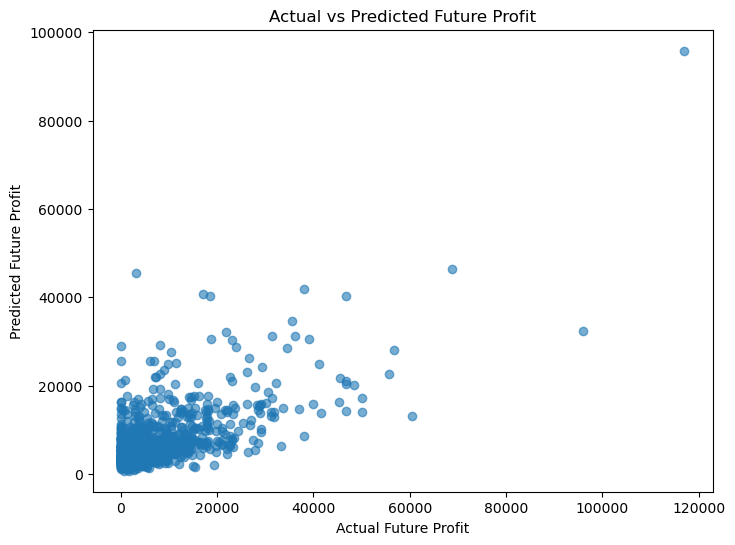

In [270]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_new,
    y_pred_new,
    alpha=0.6
)

plt.xlabel("Actual Future Profit")
plt.ylabel("Predicted Future Profit")

plt.title(
    "Actual vs Predicted Future Profit"
)

plt.show()

## Error Analysis

In [272]:
prediction_analysis = pd.DataFrame({
    "Actual_Profit": y_test_new.values,
    "Predicted_Profit": y_pred_new
})

prediction_analysis["Error"] = (
    prediction_analysis["Actual_Profit"]
    - prediction_analysis["Predicted_Profit"]
)

prediction_analysis["Absolute_Error"] = (
    prediction_analysis["Error"].abs()
)

prediction_analysis.head(10)

,Actual_Profit,Predicted_Profit,Error,Absolute_Error
0,1103.460286,3642.113939,-2538.653653,2538.653653
1,15049.399939,1840.315484,13209.084456,13209.084456
2,5410.153257,5914.075624,-503.922367,503.922367
3,0.000000,7904.752628,-7904.752628,7904.752628
4,8541.672559,13296.721786,-4755.049227,4755.049227
5,0.000000,10036.336646,-10036.336646,10036.336646
6,3469.046480,4322.488848,-853.442368,853.442368
7,10338.436711,10910.502686,-572.065975,572.065975
8,5401.840230,5562.059381,-160.219151,160.219151
9,6153.970883,4933.745669,1220.225214,1220.225214


## Largest Prediction Errors

In [275]:
prediction_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).head(10)

,Actual_Profit,Predicted_Profit,Error,Absolute_Error
94,95912.523943,32449.492158,63463.031784,63463.031784
556,60505.795401,13074.113142,47431.682259,47431.682259
218,3208.687765,45562.633721,-42353.945956,42353.945956
251,50145.397538,13967.746451,36177.651086,36177.651086
25,55782.067813,22648.715976,33133.351837,33133.351837
484,50084.368636,17162.812683,32921.555954,32921.555954
892,46754.719804,14211.529387,32543.190418,32543.190418
508,38141.691024,8516.818580,29624.872444,29624.872444
916,0.000000,29078.944189,-29078.944189,29078.944189
253,45404.239846,16422.368123,28981.871723,28981.871723


## Save Prediction Result

In [277]:
prediction_analysis.to_csv(
    "future_profit_predictions.csv",
    index=False
)

print("Prediction results saved successfully!")

Prediction results saved successfully!
